<div style="background-color:#f0f2f6; padding:15px; border-radius:10px; border-left: 5px solid #4CAF50;">
    <h3 style="color:#2c3e50; margin:0;">1. Environment Setup & Library Import</h3>
    <p style="color:#555; margin-top:5px;">
        Initializing the Python environment by importing necessary libraries for data manipulation (Pandas) and visualization (Matplotlib/Seaborn). 
        Global plotting styles are configured here for consistent aesthetics.
    </p>
</div>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')
pd.set_option('display.max_columns', 500)

<div style="background-color:#f0f2f6; padding:15px; border-radius:10px; border-left: 5px solid #2196F3;">
    <h3 style="color:#2c3e50; margin:0;">2. Data Ingestion</h3>
    <p style="color:#555; margin-top:5px;">
        Loading the raw datasets. We read the <b>Transactions</b> file (parsing dates immediately) and the <b>Articles</b> metadata file.
    </p>
</div>

In [4]:
df_trans = pd.read_csv(r'F:\Demand-Forecast\Data\transactions_train.csv', parse_dates=['t_dat'])
df_articles = pd.read_csv(r'F:\Demand-Forecast\Data\articles.csv')

<div style="background-color:#f0f2f6; padding:15px; border-radius:10px; border-left: 5px solid #FF9800;">
    <h3 style="color:#2c3e50; margin:0;">3. Temporal Scope Analysis</h3>
    <p style="color:#555; margin-top:5px;">
        Calculating the start and end dates of the dataset to understand the time horizon and calculating the total duration in days.
    </p>
</div>

In [5]:
print(df_trans.shape)
print(df_articles.shape)
print(df_trans['t_dat'].min())
print(df_trans['t_dat'].max())
print((df_trans['t_dat'].max() - df_trans['t_dat'].min()).days)

(31788324, 5)
(105542, 25)
2018-09-20 00:00:00
2020-09-22 00:00:00
733


<div style="background-color:#f0f2f6; padding:15px; border-radius:10px; border-left: 5px solid #E91E63;">
    <h3 style="color:#2c3e50; margin:0;">4. Daily Sales Volume Visualization</h3>
    <p style="color:#555; margin-top:5px;">
        Aggregating transactions by date to visualize the daily sales momentum. This reveals seasonality, spikes, and potential data gaps.
    </p>
</div>

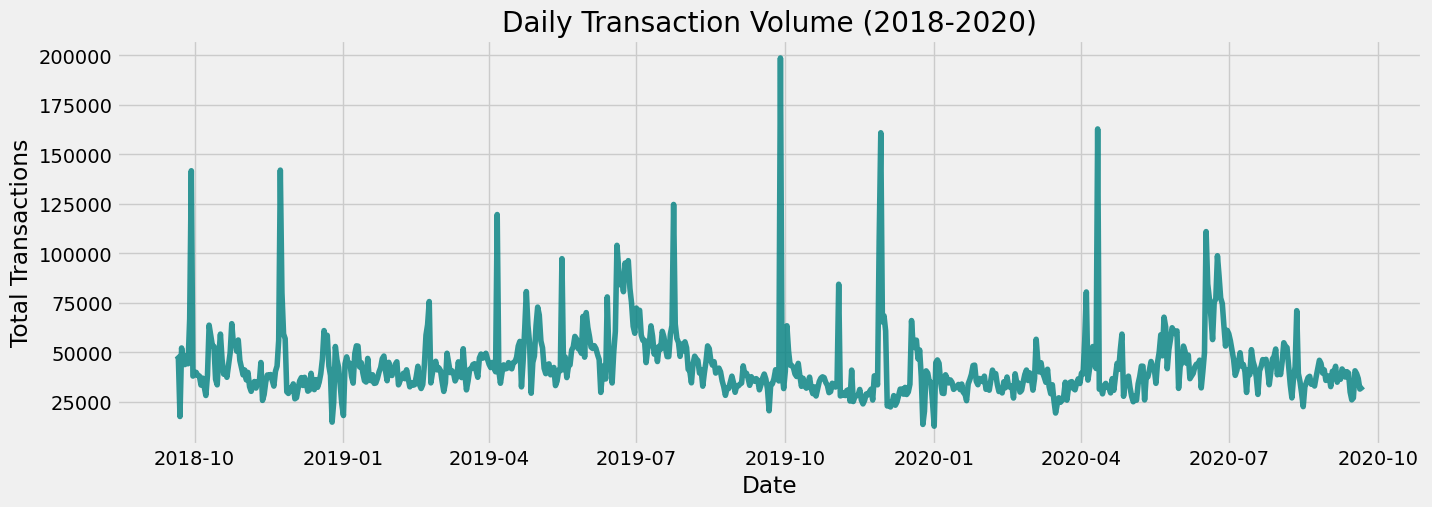

In [7]:
daily_counts = df_trans.groupby('t_dat')['article_id'].count()
plt.figure(figsize=(15, 5))
plt.plot(daily_counts.index, daily_counts.values, alpha=0.8, color='teal')
plt.title('Daily Transaction Volume (2018-2020)')
plt.xlabel('Date')
plt.ylabel('Total Transactions')
plt.show()

<div style="background-color:#f0f2f6; padding:15px; border-radius:10px; border-left: 5px solid #9C27B0;">
    <h3 style="color:#2c3e50; margin:0;">5. Hierarchy & Granularity Check</h3>
    <p style="color:#555; margin-top:5px;">
        Investigating the number of unique entities at different hierarchy levels (Item vs. Product Type vs. Product Group) to determine the optimal aggregation level for the model.
    </p>
</div>

In [8]:
n_articles = df_articles['article_id'].nunique()
n_types = df_articles['product_type_name'].nunique()
n_groups = df_articles['product_group_name'].nunique()
print(n_articles)
print(n_types)
print(n_groups)

105542
131
19


<div style="background-color:#f0f2f6; padding:15px; border-radius:10px; border-left: 5px solid #673AB7;">
    <h3 style="color:#2c3e50; margin:0;">6. Merging Metadata</h3>
    <p style="color:#555; margin-top:5px;">
        Joining the transaction data with article metadata (specifically <code>product_type_name</code>) to facilitate categorical analysis.
    </p>
</div>


In [15]:
df_merged = df_trans.merge(df_articles[['article_id', 'product_type_name']], on='article_id', how='left')
df_merged.head()

,t_dat,customer_id,article_id,price,sales_channel_id,product_type_name
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,663713001,0.050831,2,Underwear body
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,541518023,0.030492,2,Bra
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221004,0.015237,2,Sweater
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687003,0.016932,2,Sweater
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687004,0.016932,2,Sweater


In [16]:
df_merged.drop(columns=['customer_id', 'price', 'sales_channel_id'], inplace=True)

In [18]:
df_merged.head()

,t_dat,article_id,product_type_name
0,2018-09-20,663713001,Underwear body
1,2018-09-20,541518023,Bra
2,2018-09-20,505221004,Sweater
3,2018-09-20,685687003,Sweater
4,2018-09-20,685687004,Sweater


<div style="background-color:#f0f2f6; padding:15px; border-radius:10px; border-left: 5px solid #f44336;">
    <h3 style="color:#2c3e50; margin:0;">7. Sparsity Calculation</h3>
    <p style="color:#555; margin-top:5px;">
        Mathematically calculating the sparsity percentage at the <b>Product Type</b> level. This justifies the decision to aggregate by type rather than item ID to avoid the "Zero-Sales" trap.
    </p>
</div>

In [10]:
daily_sales_type = df_merged.groupby(['t_dat', 'product_type_name']).size().reset_index(name='qty')
total_possible_points = df_merged['t_dat'].nunique() * df_merged['product_type_name'].nunique()
actual_points = len(daily_sales_type)
sparsity_type = 1 - (actual_points / total_possible_points)
print(sparsity_type)

0.2815133095787047


<div style="background-color:#f0f2f6; padding:15px; border-radius:10px; border-left: 5px solid #FFC107;">
    <h3 style="color:#2c3e50; margin:0;">8. Pareto Analysis (Long Tail)</h3>
    <p style="color:#555; margin-top:5px;">
        Visualizing the cumulative sales contribution by product type. This helps identify the threshold for filtering "dead" or irrelevant categories (e.g., keeping types that contribute to 99% of sales).
    </p>
</div>

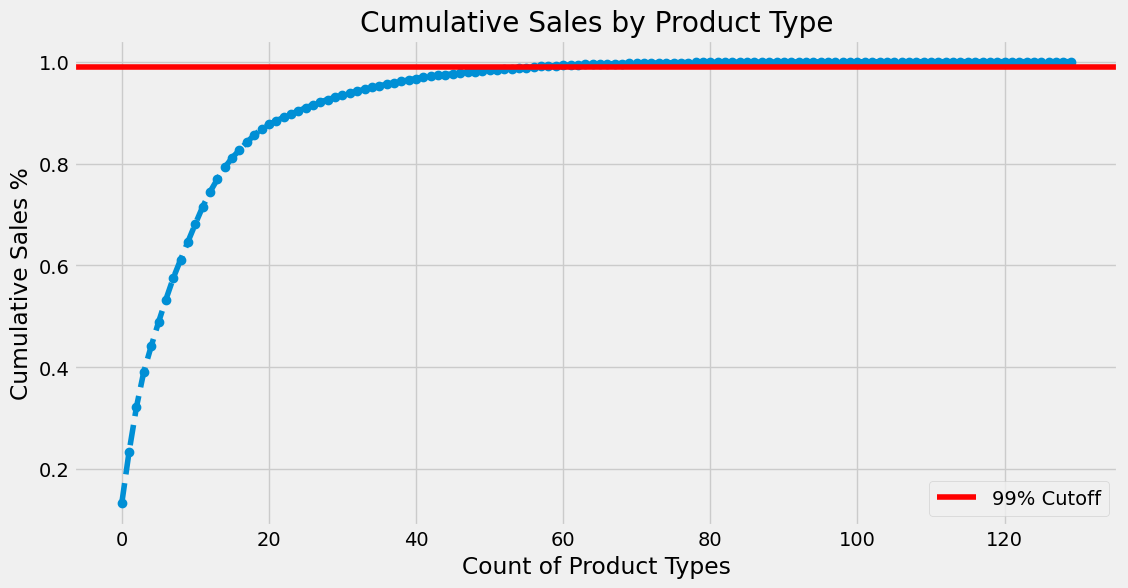

In [11]:
type_counts = df_merged['product_type_name'].value_counts()
cumulative_sales = type_counts.cumsum() / type_counts.sum()
plt.figure(figsize=(12, 6))
plt.plot(range(len(cumulative_sales)), cumulative_sales, marker='o', linestyle='--')
plt.axhline(y=0.99, color='r', linestyle='-', label='99% Cutoff')
plt.title('Cumulative Sales by Product Type')
plt.xlabel('Count of Product Types')
plt.ylabel('Cumulative Sales %')
plt.legend()
plt.show()

<div style="background-color:#f0f2f6; padding:15px; border-radius:10px; border-left: 5px solid #3F51B5;">
    <h3 style="color:#2c3e50; margin:0;">9. Seasonality Heatmap (Input Validation)</h3>
    <p style="color:#555; margin-top:5px;">
        Validating the choice of <code>product_type_name</code> as the model input. 
        This heatmap visualizes the sales intensity of the Top 20 product types over time. 
        Distinct "hot spots" during specific months confirm strong seasonal patterns that the PatchTST model can leverage for accurate forecasting.
    </p>
</div>

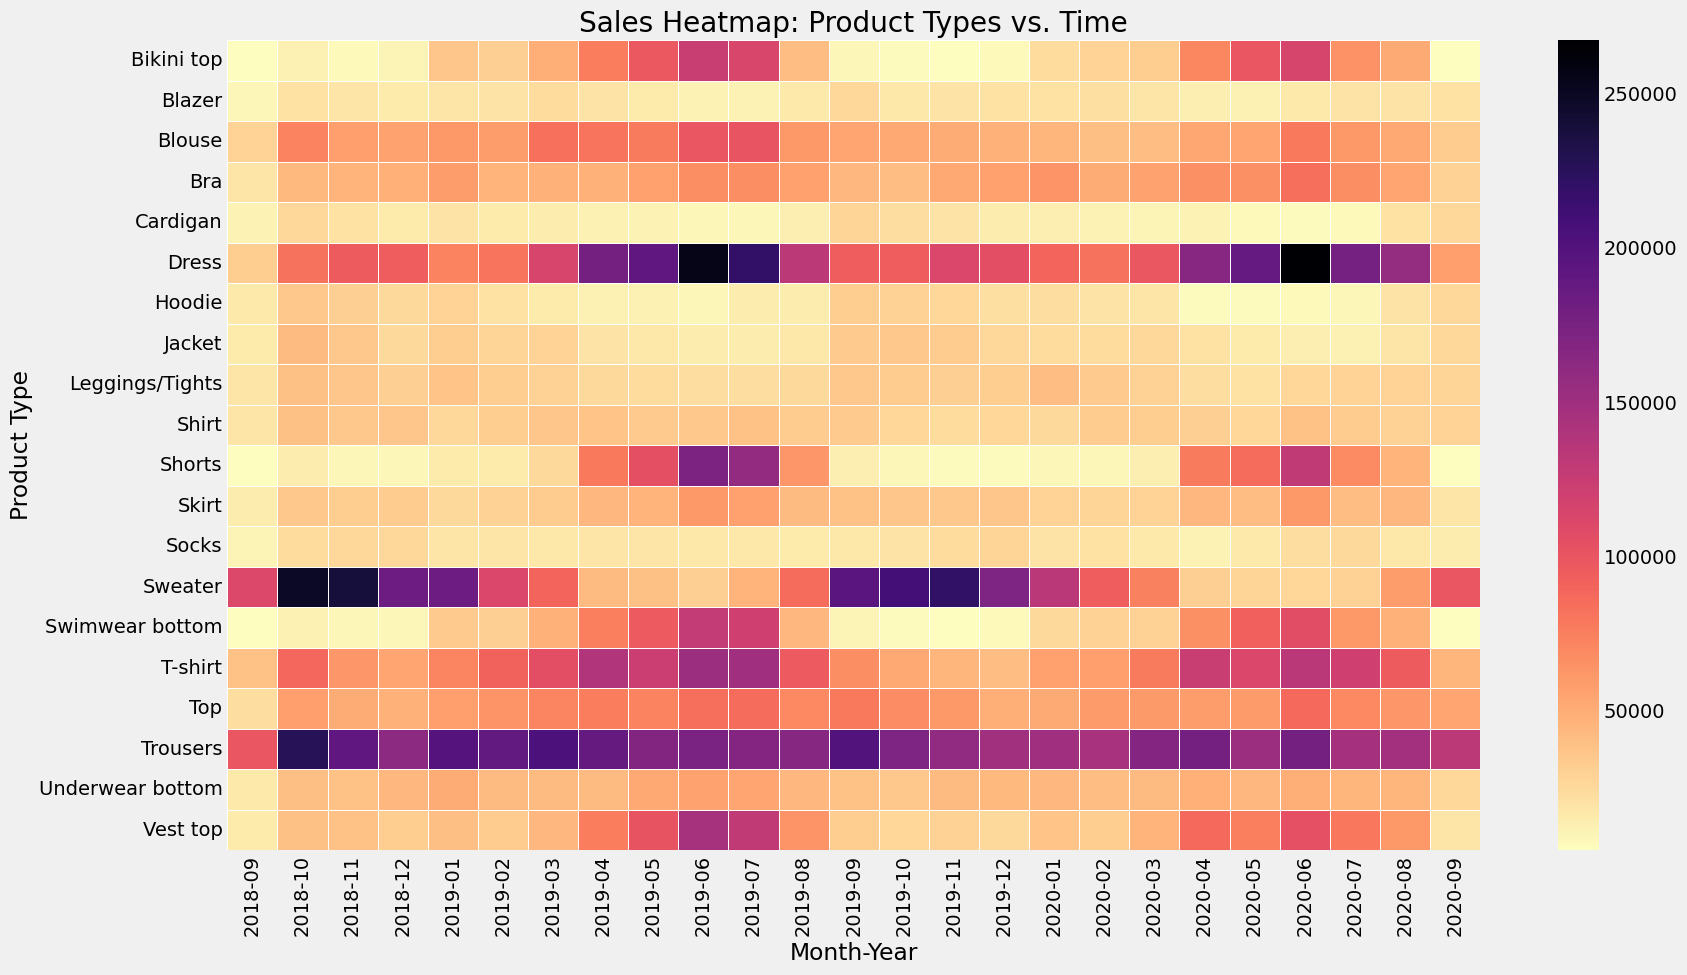

In [12]:
top_types = df_merged['product_type_name'].value_counts().head(20).index
df_top = df_merged[df_merged['product_type_name'].isin(top_types)].copy()

df_top['month_year'] = df_top['t_dat'].dt.to_period('M')

heatmap_data = df_top.groupby(['product_type_name', 'month_year']).size().unstack(fill_value=0)

plt.figure(figsize=(18, 10))
sns.heatmap(heatmap_data, cmap='magma_r', linewidths=0.5, linecolor='white')
plt.title('Sales Heatmap: Product Types vs. Time')
plt.xlabel('Month-Year')
plt.ylabel('Product Type')
plt.yticks(rotation=0)
plt.show()